**Smart Hydro Forecast: AI-Based Hydroelectric Generation Prediction**

1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")


2. Upload file

In [2]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


3. Load Dataset

In [3]:
df = pd.read_csv("data.csv")

4. Understanding Dataset

In [4]:
df.head()
df.tail()
df.shape
df.columns
df.info()
df.describe()
df.dtypes
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62810 entries, 0 to 62809
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   DateTime       62810 non-null  object
 1   Consumption    62810 non-null  int64 
 2   Production     62810 non-null  int64 
 3   Nuclear        62810 non-null  int64 
 4   Wind           62810 non-null  int64 
 5   Hydroelectric  62810 non-null  int64 
 6   Oil and Gas    62810 non-null  int64 
 7   Coal           62810 non-null  int64 
 8   Solar          62810 non-null  int64 
 9   Biomass        62810 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 4.8+ MB
DateTime         object
Consumption       int64
Production        int64
Nuclear           int64
Wind              int64
Hydroelectric     int64
Oil and Gas       int64
Coal              int64
Solar             int64
Biomass           int64
dtype: object


5. Exploratory Data Analysis (EDA)

In [5]:
#Missing Values
df.isnull().sum()

,0
DateTime,0
Consumption,0
Production,0
Nuclear,0
Wind,0
Hydroelectric,0
Oil and Gas,0
Coal,0
Solar,0
Biomass,0


In [6]:
#Duplicate Values
df.duplicated().sum()

np.int64(4)

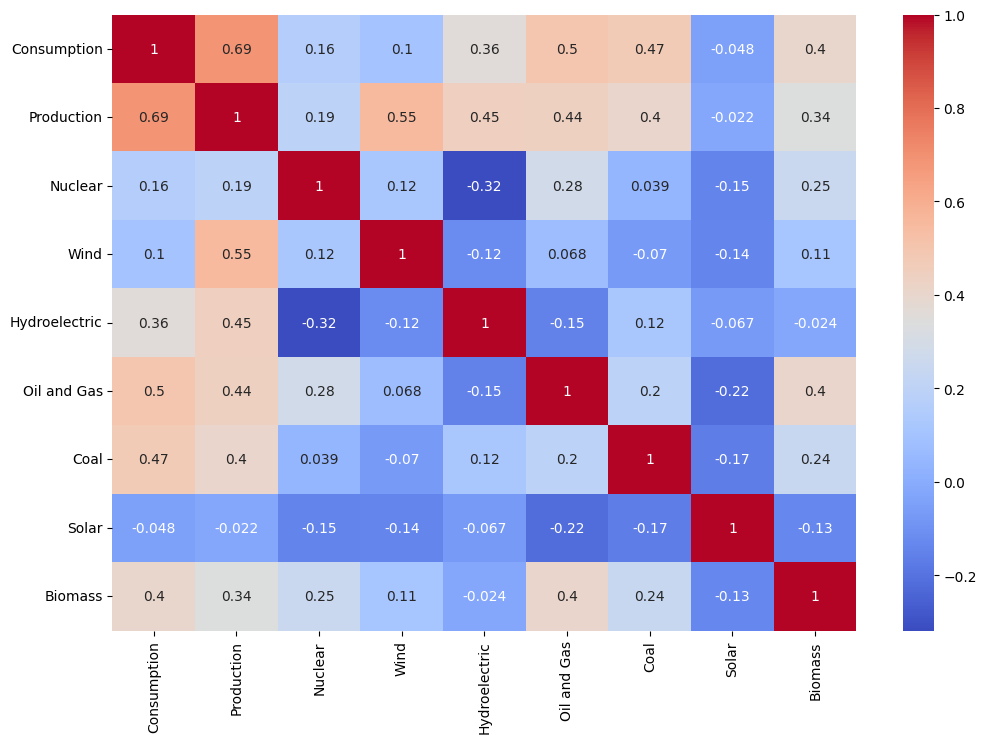

In [7]:
#Correlation
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

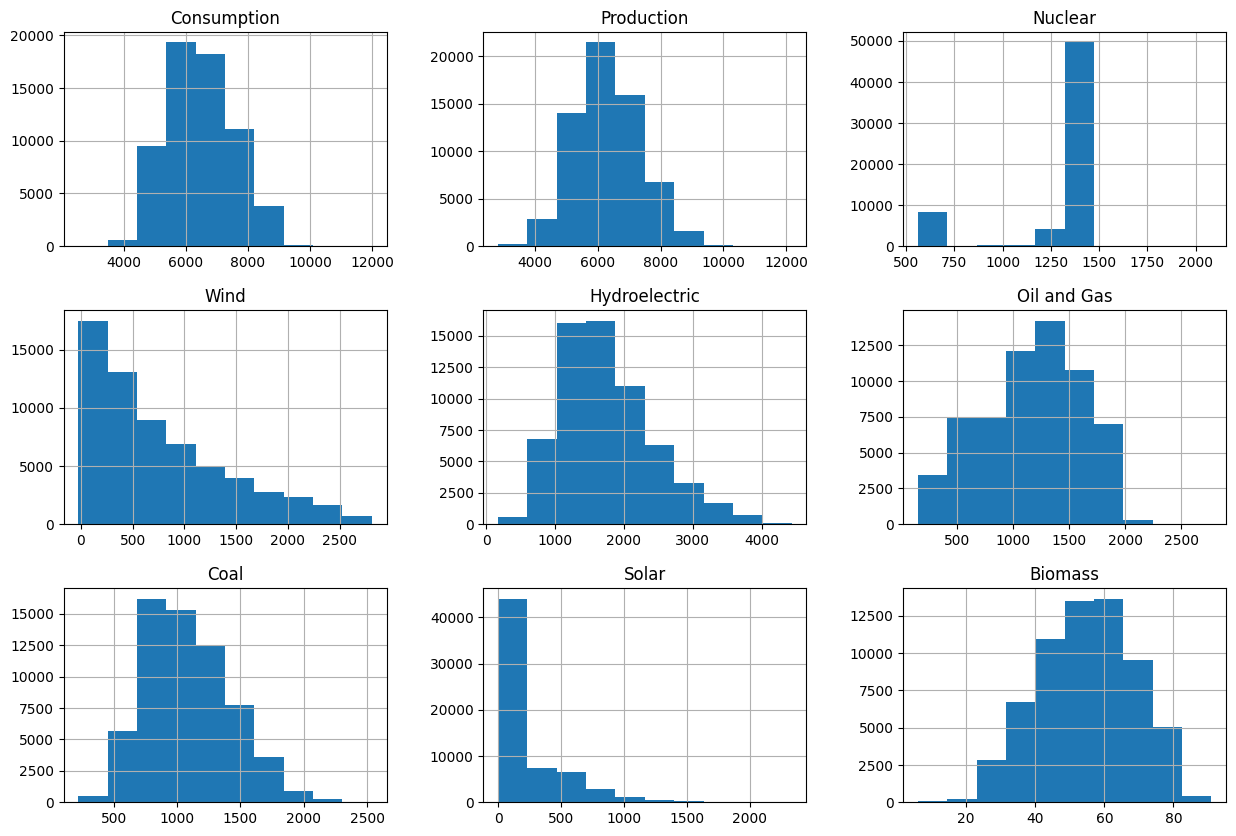

In [8]:
#Distribution
df.hist(figsize=(15,10))
plt.show()

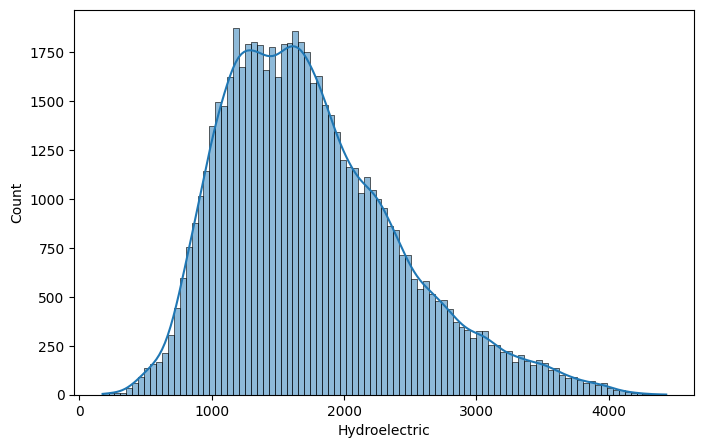

In [9]:
#Hydroelectric Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Hydroelectric"], kde=True)
plt.show()

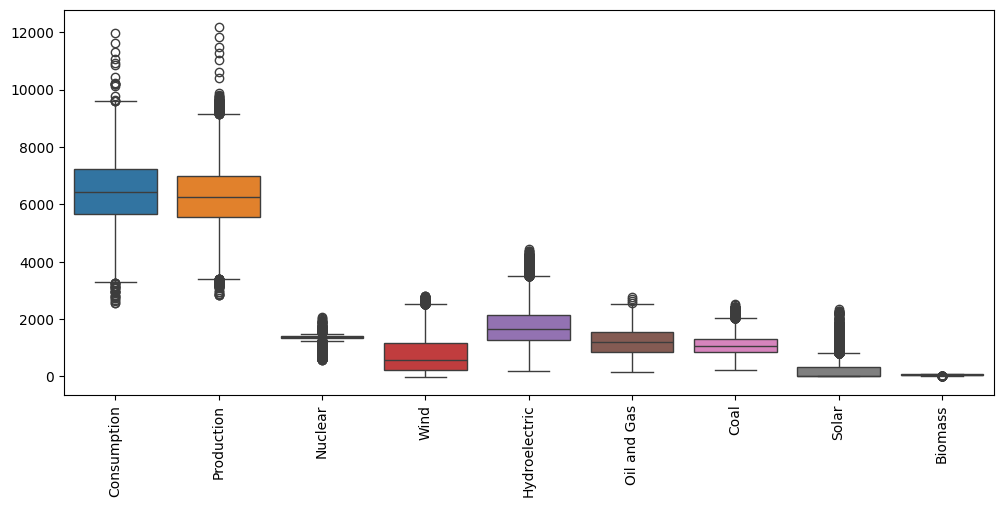

In [10]:
#Boxplot
plt.figure(figsize=(12,5))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

6. Data Cleaning

In [11]:
#Convert Date column
df["DateTime"] = pd.to_datetime(df["DateTime"])

In [12]:
#Check missing values
df.isnull().sum()

,0
DateTime,0
Consumption,0
Production,0
Nuclear,0
Wind,0
Hydroelectric,0
Oil and Gas,0
Coal,0
Solar,0
Biomass,0


In [13]:
#Remove duplicates
df = df.drop_duplicates()

7. Feature Engineering

In [14]:
#Extract useful DateTime features.

df["Year"] = df["DateTime"].dt.year
df["Month"] = df["DateTime"].dt.month
df["Day"] = df["DateTime"].dt.day
df["Hour"] = df["DateTime"].dt.hour
df["Weekday"] = df["DateTime"].dt.weekday

In [15]:
#Drop original DateTime
df = df.drop("DateTime", axis=1)

8. Feature Selection

In [16]:
#Target Variable
y = df["Hydroelectric"]

In [17]:
#Features
X = df.drop("Hydroelectric", axis=1)

9. Encoding Categorical Data


In [18]:
#There are no categorical columns in this dataset.
print("No Encoding Required")

No Encoding Required


10. Feature Scaling


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

11. Train Test Split


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

12. Choose ML Algorithms (Regression)


In [21]:
#Algorithm 1: Linear Regression

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [22]:
#Algorithm 2: Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [23]:
#Algorithm 3: Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [24]:
#Algorithm 4: XGBoost Regressor (Recommended)

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [25]:
#Compare All Models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for name, pred in models.items():
    print("=" * 50)
    print(name)
    print("MAE :", mean_absolute_error(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("R² Score:", r2_score(y_test, pred))

Linear Regression
MAE : 9.874482731358098
RMSE: 30.855495172106465
R² Score: 0.9979226465846339
Decision Tree
MAE : 137.27654832033116
RMSE: 200.7192095506311
R² Score: 0.9120930476846097
Random Forest
MAE : 85.64662951759274
RMSE: 116.82613720318014
R² Score: 0.9702199527874181
XGBoost
MAE : 85.08094787597656
RMSE: 110.11419853384031
R² Score: 0.9735435247421265


In [26]:
#Select the Best Model
scores = {
    "Linear Regression": r2_score(y_test, lr_pred),
    "Decision Tree": r2_score(y_test, dt_pred),
    "Random Forest": r2_score(y_test, rf_pred),
    "XGBoost": r2_score(y_test, xgb_pred)
}

best_model_name = max(scores, key=scores.get)

print("Best Model:", best_model_name)
print("Best R² Score:", scores[best_model_name])

Best Model: Linear Regression
Best R² Score: 0.9979226465846339


13. Train Model


In [27]:
lr_model.fit(X_train, y_train)

LinearRegression()

14. Make Prediction


In [28]:
y_pred = lr_model.predict(X_test)

15. Evaluate Model


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 9.874482731358098
RMSE: 30.855495172106465
R² Score: 0.9979226465846339


16. Hyperparameter Tuning


In [30]:
# Create Linear Regression Model
lr = LinearRegression()

# Define Hyperparameter Grid
param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

# Apply GridSearchCV
grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train Grid Search
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(), n_jobs=-1,
             param_grid={'fit_intercept': [True, False],
                         'positive': [True, False]},
             scoring='r2')

In [32]:
# Best Parameters
print("Best Parameters:", grid.best_params_)

Best Parameters: {'fit_intercept': True, 'positive': False}


In [33]:
# Best Cross Validation Score
print("Best R² Score:", grid.best_score_)

Best R² Score: 0.9982153000973385


17. Best Model

In [34]:
best_model = grid.best_estimator_

In [35]:
#Predict
pred = best_model.predict(X_test)

print(r2_score(y_test,pred))


0.9979226465846339


18. Save Model

In [36]:
import joblib

joblib.dump(lr_model, "linear_regression_model.pkl")


['linear_regression_model.pkl']

In [37]:
#Save scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

19. Load Saved Model

In [38]:

model = joblib.load("linear_regression_model.pkl")

scaler = joblib.load("scaler.pkl")

20. Make New Prediction


In [39]:
sample = [[
6200,   # Consumption
6500,   # Production
1200,   # Nuclear
400,    # Wind
800,    # Oil and Gas
1800,   # Coal
250,    # Solar
40,     # Biomass
2025,   # Year
7,      # Month
14,      # Day
15,      # Hour
1        # Weekday
]]

sample = scaler.transform(sample)

prediction = model.predict(sample)

print("Predicted Hydroelectric Generation:", prediction[0])

Predicted Hydroelectric Generation: 2001.0599392477666
